In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

plt.rcParams["font.family"] = "Times New Roman"

PATH = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\dati\\hawkes\\orderbook_changes\\BTC_USD"
path = Path(PATH)

In [2]:
files = list(path.glob("orderbook_changes_*.tsv"))
dfs = [pd.read_csv(f, sep="\t") for f in files]
df = pd.concat(dfs, ignore_index=True)
df["MidPrice"] = (df["AskPrice1"] + df["BidPrice1"]) / 2
df["Return"] = (-df["MidPrice"] + df["MidPrice"].shift(-1)) / df["MidPrice"]

pbid = df["BidPrice1"] - df[f"BidPrice5"]
pask = df[f"AskPrice5"] - df["AskPrice1"]
df["BaseImbalance"] = (pbid - pask) / (pbid + pask)
df["TimeOffset"] = df["Timestamp"] - df["Timestamp"].shift(1)
df.head()

,AskPrice1,AskSize1,AskPrice2,AskSize2,AskPrice3,AskSize3,AskPrice4,AskSize4,AskPrice5,AskSize5,...,BidPrice26,BidSize26,AskPrice26,AskSize26,AskPrice27,AskSize27,MidPrice,Return,BaseImbalance,TimeOffset
0,45301,3.169369,45304,0.113010,45309.0,0.01100,45310.0,0.01100,45312.0,0.16962,...,NaN,NaN,NaN,NaN,NaN,NaN,45300.5,0.0,-0.294118,NaN
1,45301,3.119589,45304,0.113010,45309.0,0.01100,45310.0,0.01100,45312.0,0.16962,...,NaN,NaN,NaN,NaN,NaN,NaN,45300.5,0.0,-0.294118,233.0
2,45301,3.119589,45302,0.002650,45303.0,0.16962,45304.0,0.11036,45306.0,0.75000,...,NaN,NaN,NaN,NaN,NaN,NaN,45300.5,0.0,0.090909,232.0
3,45301,3.548009,45302,0.016771,45304.0,0.11036,45306.0,0.75000,45309.0,0.01100,...,NaN,NaN,NaN,NaN,NaN,NaN,45300.5,0.0,-0.142857,227.0
4,45301,3.550659,45302,0.764121,45304.0,0.11036,45309.0,0.01100,45310.0,0.01100,...,NaN,NaN,NaN,NaN,NaN,NaN,45300.5,0.0,-0.200000,227.0


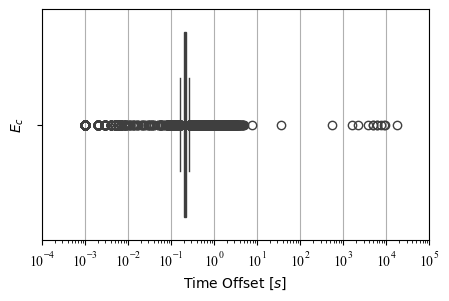

In [3]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df[df["Return"] != 0]["TimeOffset"] / 1e3)
plt.xscale("log")
plt.xlabel(r"$\text{Time Offset }[s]$")
plt.ylabel(r"$E_c$")
plt.xlim(1e-4, 1e5)
plt.grid(axis="x")
plt.savefig(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\images\\time_offsets.eps",
    format="eps",
    bbox_inches="tight",
)

plt.show()

In [29]:
df[["BaseImbalance", "Return"]].corr(method="pearson")

,BaseImbalance,Return
BaseImbalance,1.0000,-0.1149
Return,-0.1149,1.0000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


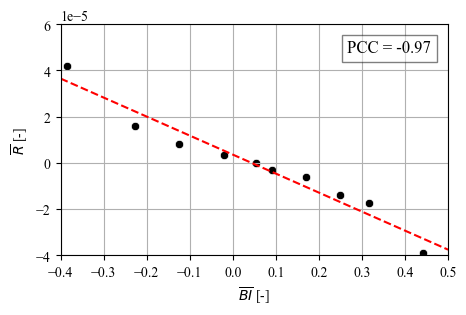

In [17]:
corr, _ = pearsonr(df_plot["BaseImbalance"], df_plot["Return"])

# Create scatter plot
plt.figure(figsize=(5, 3))
sns.scatterplot(
    x="BaseImbalance",
    y="Return",
    data=df_plot,
    alpha=1,
    color="black",
)

# Fit regression line manually
slope, intercept = np.polyfit(df_plot["BaseImbalance"], df_plot["Return"], 1)
x_range = np.array([-0.4, 0.5])  # Extend to your xlim bounds
y_range = slope * x_range + intercept

# Plot the regression line
plt.plot(
    x_range,
    y_range,
    color="red",
    linestyle="--",
    linewidth=1.5,
)

# Add Pearson correlation annotation
plt.text(
    0.74,
    0.88,
    f"PCC = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.5),
)

# Labels and limits
plt.xlabel(r"$\overline{BI}$ [-]")
plt.ylabel(r"$\overline{R}$ [-]")
plt.xlim(-0.4, 0.5)
plt.ylim(-4 * 1e-5, 6 * 1e-5)
plt.grid(True)

# Show the plot
plt.savefig(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\images\\pcc.eps",
    format="eps",
    bbox_inches="tight",
)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


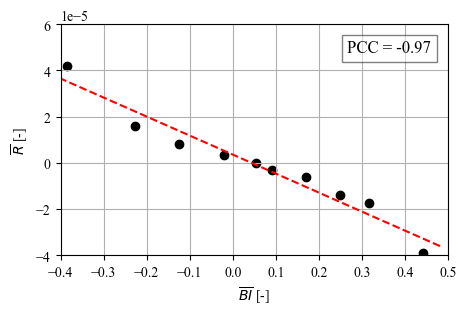

In [13]:
# divide dataset in deciles based on BaseImbalance and compute the average Return and BaseImbalance for each decile
df = df[df["Return"] != 0]
df["BaseImbalanceDecile"] = pd.qcut(df["BaseImbalance"], 10, labels=False)
df_plot = (
    df.groupby("BaseImbalanceDecile")[["BaseImbalance", "Return"]].mean().reset_index()
)
from scipy.stats import pearsonr

corr, _ = pearsonr(df_plot["BaseImbalance"], df_plot["Return"])

# Create scatter plot with regression line
plt.figure(figsize=(5, 3))
sns.regplot(
    x="BaseImbalance",
    y="Return",
    data=df_plot,
    scatter_kws={"alpha": 1},
    line_kws={"color": "red", "linestyle": "--", "linewidth": 1.5},
    ci=None,
    truncate=False,
    color="black",
)

# Add Pearson correlation annotation
plt.text(
    0.74,
    0.88,
    f"PCC = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.5),
)

# Labels and title
plt.xlabel(r"$\overline{BI}$ [-]")
plt.ylabel(r"$\overline{R}$ [-]")
plt.xlim(-0.4, 0.5)
plt.ylim(-4 * 1e-5, 6 * 1e-5)
plt.grid(True)
# Show the plot
plt.savefig(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\images\\pcc.pdf",
    format="eps",
    bbox_inches="tight",
)
plt.show()